In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 2.0
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
ts = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/ts_ssp5.nc').ts

In [45]:
pr = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/pr_ssp5.nc').pr*86400*30

In [6]:
u10 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/uas_ssp5.nc').uas
v10 = xr.open_dataset('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/new/vas_ssp5.nc').vas

In [7]:
ts

<xarray.DataArray 'ts' (model: 47, time: 250, lat: 120, lon: 240)>
[338400000 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 352.5 354.0 355.5 357.0 358.5
  * lat      (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'

In [8]:
ts_pi = ts.sel(time = slice('1850', '1900')).mean('time')

In [46]:
pr_pi = pr.sel(time = slice('1850', '1900')).mean('time')

In [9]:
u10_pi = u10.sel(time = slice('1850', '1900')).mean('time')
v10_pi = v10.sel(time = slice('1850', '1900')).mean('time')

In [10]:
ts_eoc = ts.sel(time = slice('2050', '2100')).mean('time')

In [47]:
pr_eoc = pr.sel(time = slice('2050', '2100')).mean('time')

In [11]:
u10_eoc = u10.sel(time = slice('2050', '2100')).mean('time')
v10_eoc = v10.sel(time = slice('2050', '2100')).mean('time')

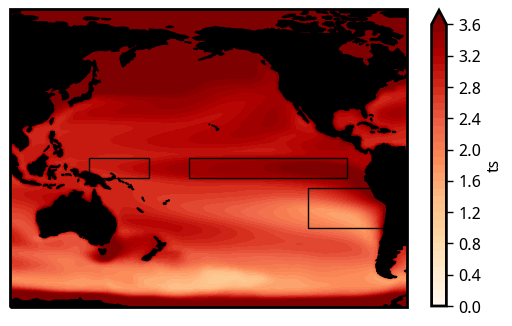

In [166]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(ts_eoc - ts_pi).mean('model').plot.contourf(cmap='OrRd', levels=np.arange(0,3.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8))
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

In [96]:
ws_pi = np.sqrt(u10_pi**2 + v10_pi**2)
ws_eoc = np.sqrt(u10_eoc**2 + v10_eoc**2)

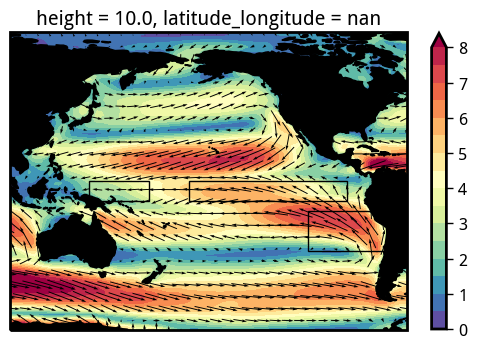

In [168]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(ws_pi).mean('model').plot.contourf(cmap='Spectral_r', levels=np.arange(0, 8.5, 0.5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
xr.merge([u10_pi, v10_pi]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=0, vmax=8, extend='both', scale=100, robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

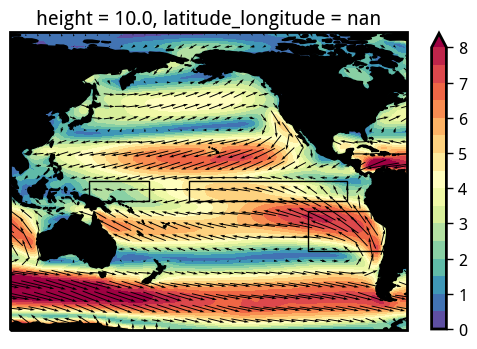

In [170]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(ws_eoc).mean('model').plot.contourf(cmap='Spectral_r', levels=np.arange(0,8.5,0.5), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
xr.merge([u10_eoc, v10_eoc]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=0, vmax=8, extend='both', scale=100, robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

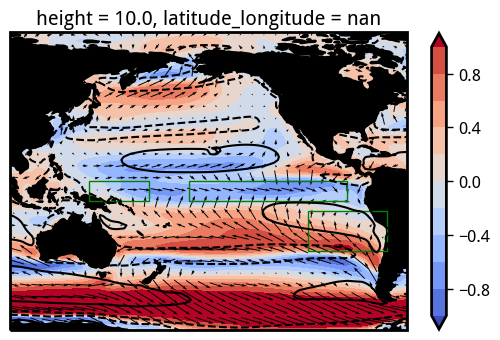

In [180]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(ws_eoc - ws_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-1, 1.2, 0.2), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
(ws_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree(), linestyles=['--', '-'])
xr.merge([u10_eoc-u10_pi, v10_eoc-v10_pi]).mean('model').isel(lon = slice(0,-1,4), lat = slice(0,-1,4)).plot.quiver(x="lon", y="lat", u="uas", v="vas", vmin=-1, vmax=1, scale=20, robust=True, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)

# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='g',
                                transform=ccrs.PlateCarree()))


In [130]:
import matplotlib.patches as mpatches

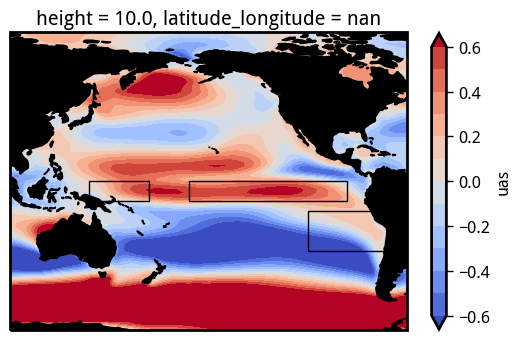

In [185]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(u10_eoc - u10_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-0.6, 0.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
# (u10_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

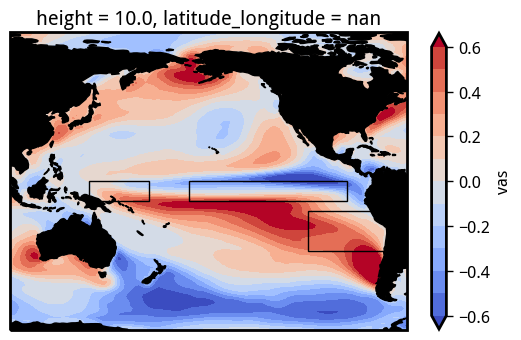

In [186]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(v10_eoc - v10_pi).mean('model').plot.contourf(cmap='coolwarm', levels=np.arange(-0.6, 0.7, 0.1), transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
# (u10_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)
# ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
#                                 facecolor='none', edgecolor='k',
#                                 transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([100, 300, -70, 80], crs=ccrs.PlateCarree())
(u10_eoc - u10_pi).mean('model').plot(cmap='coolwarm',  transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='vertical', shrink=0.8), robust=True)
# (u10_pi).mean('model').plot.contour(colors='k', center=4, levels=np.array([2, 6]), transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='k', zorder=1)

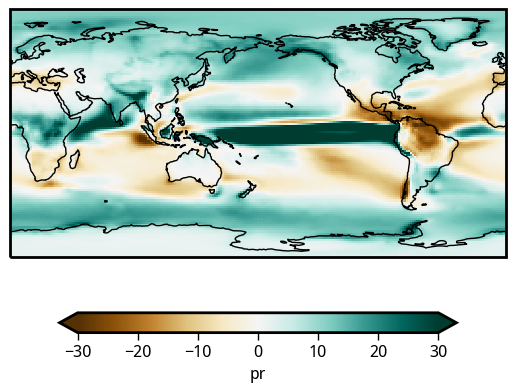

In [69]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
(pr_eoc - pr_pi).mean('model').plot(cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-30, cbar_kwargs=dict(orientation='horizontal', shrink=0.8))
ax.coastlines()